# 01 - Análisis exploratorio (EDA)
Dataset Blood Cells (4 clases). Objetivo: conocer balance de clases, tamaños, ejemplos y estadísticas de píxeles para normalizar.

In [1]:
import sys; sys.path.append('../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from utils import set_seed, DATA_DIR, CLASSES, FIG_DIR, SEED, ROOT
set_seed(SEED)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_DIR.exists())

True


## 1. Conteo por split y clase

split       TEST  TRAIN  TOTAL
clase                         
EOSINOPHIL   623   2497   3120
LYMPHOCYTE   620   2483   3103
MONOCYTE     620   2478   3098
NEUTROPHIL   624   2499   3123
split
TEST      2487
TRAIN     9957
TOTAL    12444
dtype: int64


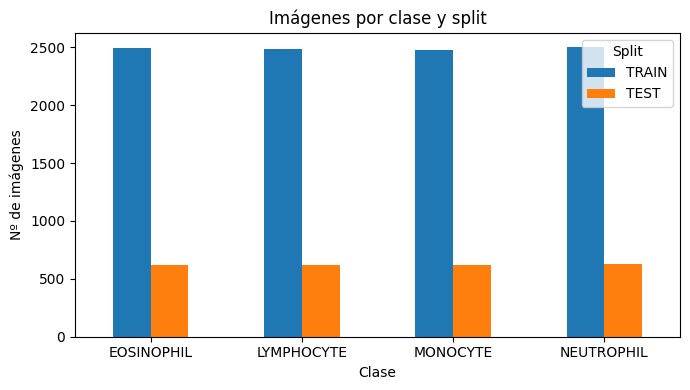

In [2]:
rows = []
for split in ['TRAIN', 'TEST']:
    for c in CLASSES:
        rows.append((split, c, len(list((DATA_DIR/split/c).glob('*.jpeg')))))
df = pd.DataFrame(rows, columns=['split', 'clase', 'n'])
tab = df.pivot(index='clase', columns='split', values='n')
tab['TOTAL'] = tab.sum(axis=1)
print(tab); print(tab.sum())

ax = tab[['TRAIN', 'TEST']].plot(kind='bar', figsize=(7, 4), rot=0)
ax.set_title('Imágenes por clase y split'); ax.set_xlabel('Clase'); ax.set_ylabel('Nº de imágenes')
ax.legend(title='Split'); plt.tight_layout(); plt.savefig(FIG_DIR/'eda_conteo_clases.png', dpi=150); plt.show()

## 2. Ejemplos por clase

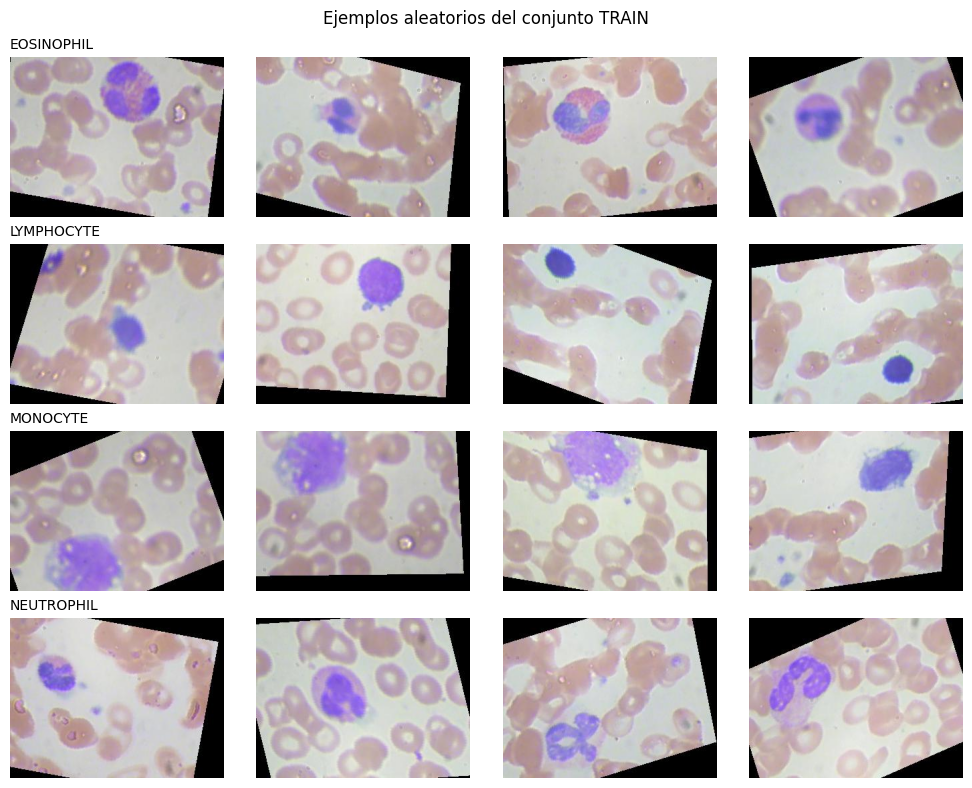

In [3]:
rng = np.random.default_rng(SEED)
fig, axs = plt.subplots(4, 4, figsize=(10, 8))
for i, c in enumerate(CLASSES):
    files = sorted((DATA_DIR/'TRAIN'/c).glob('*.jpeg'))
    for j, f in enumerate(rng.choice(files, 4, replace=False)):
        axs[i, j].imshow(Image.open(f)); axs[i, j].axis('off')
        if j == 0: axs[i, j].set_title(c, loc='left', fontsize=10)
fig.suptitle('Ejemplos aleatorios del conjunto TRAIN'); plt.tight_layout()
plt.savefig(FIG_DIR/'eda_ejemplos.png', dpi=150); plt.show()

## 3. Tamaño y modo de las imágenes

In [4]:
sizes = {}
for c in CLASSES:
    for f in list((DATA_DIR/'TRAIN'/c).glob('*.jpeg'))[:300]:
        im = Image.open(f); sizes[(im.size, im.mode)] = sizes.get((im.size, im.mode), 0) + 1
print(sizes)

{((320, 240), 'RGB'): 1200}


## 4. Media y desviación por canal (TRAIN, a 64×64)
Se usarán para normalizar.

In [5]:
acc, acc2, n = np.zeros(3), np.zeros(3), 0
for c in CLASSES:
    for f in (DATA_DIR/'TRAIN'/c).glob('*.jpeg'):
        a = np.asarray(Image.open(f).convert('RGB').resize((64, 64)), dtype=np.float64) / 255
        acc += a.sum((0, 1)); acc2 += (a**2).sum((0, 1)); n += a.shape[0]*a.shape[1]
mean = acc/n; std = np.sqrt(acc2/n - mean**2)
print('mean =', mean.round(4).tolist()); print('std  =', std.round(4).tolist())

mean = [0.6791, 0.6418, 0.661]
std  = [0.2587, 0.258, 0.2556]


## 5. ¿Qué tan parecidos son val y test a TRAIN?
Las validaciones salen ~95-100 % y test ~65-86 %. Se compara, para cada imagen, la similitud coseno con su vecino más cercano en TRAIN usando embeddings de una ResNet-18 preentrenada (128×128). Referencia: TRAIN contra el resto de TRAIN.

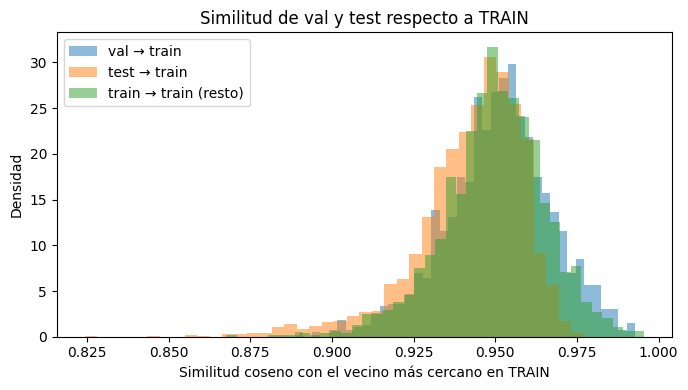

,Comparación,Mediana,p10,p90,Frac > 0.95,Frac > 0.98
0,val → train,0.952,0.930,0.971,0.544,0.034
1,test → train,0.945,0.922,0.960,0.364,0.000
2,train → train (resto),0.950,0.930,0.969,0.512,0.020


In [6]:
import torch, torch.nn.functional as F
from torchvision import models
from utils import get_loaders, MEAN_IMAGENET, STD_IMAGENET
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tr, va, te = get_loaders(128, 128, mean=MEAN_IMAGENET, std=STD_IMAGENET)
net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1); net.fc = torch.nn.Identity(); net.to(dev).eval()

@torch.no_grad()
def emb(ds):
    out = []
    for i in range(0, len(ds), 256):
        x = torch.stack([ds[j][0] for j in range(i, min(i+256, len(ds)))]).to(dev)
        out.append(F.normalize(net(x), dim=1))
    return torch.cat(out)

Etr, Eva, Ete = emb(tr.dataset), emb(va.dataset), emb(te.dataset)
nn_sim = lambda a, b: (a @ b.T).max(1).values.cpu().numpy()
sims = {'val → train': nn_sim(Eva, Etr), 'test → train': nn_sim(Ete, Etr), 'train → train (resto)': nn_sim(Etr[:1500], Etr[1500:])}
rows = [{'Comparación': k, 'Mediana': round(float(np.median(v)), 3), 'p10': round(float(np.percentile(v, 10)), 3),
         'p90': round(float(np.percentile(v, 90)), 3), 'Frac > 0.95': round(float((v > .95).mean()), 3),
         'Frac > 0.98': round(float((v > .98).mean()), 3)} for k, v in sims.items()]
leak = pd.DataFrame(rows); leak.to_csv(ROOT/'results'/'eda_similitud_splits.csv', index=False)
plt.figure(figsize=(7, 4))
for k, v in sims.items(): plt.hist(v, bins=40, alpha=.5, density=True, label=k)
plt.xlabel('Similitud coseno con el vecino más cercano en TRAIN'); plt.ylabel('Densidad')
plt.title('Similitud de val y test respecto a TRAIN'); plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR/'eda_similitud_splits.png', dpi=150); plt.show()
leak

## Conclusiones del EDA
- Clases balanceadas (≈2 480-2 500 imágenes por clase en TRAIN): accuracy es una métrica válida.
- Imágenes RGB de 320×240; se redimensionarán a 64×64 (LeNet/VGG) y 224×224 (transfer learning).
- No hay split de validación: se separará 15 % de TRAIN, estratificado, con semilla 42.
- No se encuentran duplicados exactos entre splits, pero val se parece algo más a TRAIN que test (mediana de similitud 0.952 vs 0.945): evidencia moderada de que la validación es optimista respecto a test. No se prueba la causa.